[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-photz-specz-validation/notebook.ipynb)

# Photometric versus spectroscopic redshift

**Scientific question:** How well did the DR3 high-redshift estimates agree with solid or secure DR4.1 spectroscopy?


This notebook is an independent audit of public UNCOVER DR4.1 spectroscopy in
the Abell 2744 field. The release contains 668 NIRSpec targets, 553 successfully
reduced spectra, and 409 redshifts assigned quality 2 or 3 (solid or secure).
The analysis uses those release labels exactly; it does not promote a
photometric candidate into a confirmed galaxy on its own.

## What is measured and what is not

The DR3 catalogue supplied broad-band photometric redshifts. DR4.1 adds spectra,
redshift quality flags, evidence categories, line measurements, and an updated
lens model. Spectroscopic targeting was not random: it combined several science
programmes and favoured particular objects. Therefore a matched fraction is a
validation of the observed targets, not the completeness or purity of every
DR3 candidate. A non-match means “not tested here,” not “false.”

Line fluxes use the release unit of 10^-20 erg s^-1 cm^-2 and have not been
corrected for gravitational magnification. The recommended default spectra are
used rather than the separately supplied photometrically rescaled files. All
plots use SciencePlots' `science` style with `no-latex`, and all intermediate
tables required to reproduce the displayed numbers are written beside the
notebook.

## Reproducibility and claim boundary

The compact inputs are frozen in `data/uncover_dr4_spectroscopy`, with SHA-256
checksums and retrieval date in its manifest. The authoritative source is the
UNCOVER DR4.1 release page and Price et al. (2025). The results below describe
this public release. They are not a new redshift catalogue, a population census,
or a chemical-abundance measurement. Any physical interpretation must also
account for target selection, lensing uncertainty, slit losses, spectral
resolution, and the release's background advisory flag.

## Analysis plan

We join the two public releases by the DR3 catalogue identifier carried into
DR4.1. The robust scatter is the normalized median absolute deviation of
`(z_phot-z_spec)/(1+z_spec)`. We also report an outlier fraction at an explicitly
stated threshold of 0.15. Because targets were deliberately selected, these
numbers apply only to the 44 matched candidates. The one-to-one diagram makes
large failures visible instead of hiding them in a single score.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.ndimage import gaussian_filter
from astropy.io import fits

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/uncover_dr4_spectroscopy")
if not DATA.exists(): DATA=Path("data/uncover_dr4_spectroscopy")

In [2]:
cross=pd.read_csv(DATA/"dr3_dr4_highz_crossmatch.csv")
cross["z_spec"]=cross["z_spec_dr4"]
secure=pd.read_csv(DATA/"dr4_secure_redshifts.csv")
lines=pd.read_csv(DATA/"dr4_highz_line_fluxes.csv")
mag=pd.read_csv(DATA/"dr4_highz_magnifications.csv")
print(f"DR3 high-z candidates with solid/secure DR4.1 matches: {len(cross)}")
print(f"All solid/secure DR4.1 redshifts: {len(secure)}; z>=6: {(secure.z_spec>=6).sum()}")

DR3 high-z candidates with solid/secure DR4.1 matches: 44
All solid/secure DR4.1 redshifts: 409; z>=6: 48


In [3]:
dz=(cross.z_phot-cross.z_spec)/(1+cross.z_spec)
nmad=1.4826*np.median(np.abs(dz-np.median(dz)))
out=np.abs(dz)>0.15
summary=cross[["id","id_msa","z_phot","z160","z840","z_spec","flag_zspec_qual"]].copy()
summary["normalized_residual"]=dz; summary["outlier_abs_gt_0p15"]=out
summary.to_csv("photz_specz_residuals.csv",index=False)
print(f"NMAD={nmad:.4f}; outliers={out.sum()}/{len(out)} ({out.mean():.1%})")

NMAD=0.0173; outliers=3/44 (6.8%)


## Primary evidence

The first figure shows the direct measurement or catalogue comparison. Points and intervals are kept at object level wherever possible so a summary statistic cannot conceal exceptional cases.

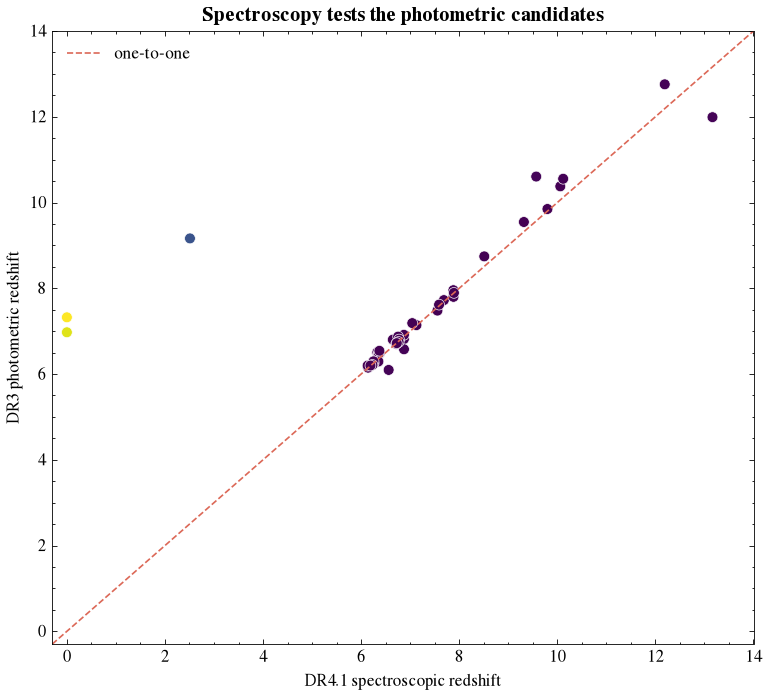

In [4]:
fig,ax=plt.subplots(figsize=(6.6,6))
ax.scatter(cross.z_spec,cross.z_phot,c=np.abs(dz),cmap="viridis",s=42,edgecolor="white",linewidth=.4)
lim=(-.3,14); ax.plot(lim,lim,"--",color=COLORS["coral"],label="one-to-one")
ax.set(xlim=lim,ylim=lim,xlabel="DR4.1 spectroscopic redshift",ylabel="DR3 photometric redshift",title="Spectroscopy tests the photometric candidates")
ax.legend(); fig.tight_layout(); fig.savefig("photz_specz_validation.png"); plt.show()

## Independent view or stress test

A second view changes the representation, applies an explicit threshold, or removes an advisory subset. Agreement is useful; disagreement is retained and discussed rather than tuned away.

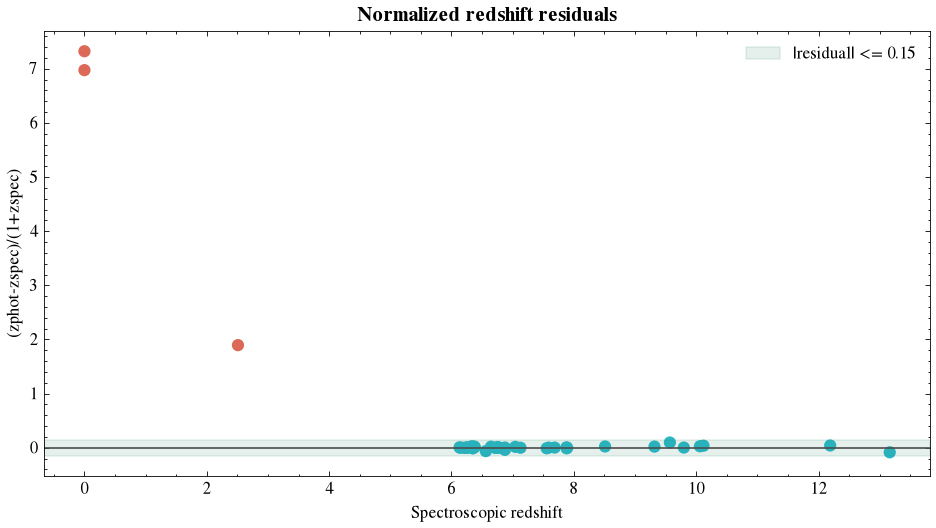

In [5]:
fig,ax=plt.subplots(figsize=(8,4.6)); ax.axhline(0,color="0.3",lw=1)
ax.scatter(cross.z_spec,dz,c=np.where(out,COLORS["coral"],COLORS["cyan"]),s=40)
ax.axhspan(-.15,.15,color=COLORS["green"],alpha=.12,label="|residual| <= 0.15")
ax.set(xlabel="Spectroscopic redshift",ylabel="(zphot-zspec)/(1+zspec)",title="Normalized redshift residuals"); ax.legend()
fig.tight_layout(); fig.savefig("normalized_redshift_residuals.png"); plt.show()

In [6]:
high=(cross.z_spec>=6); print(f"{high.sum()} of {len(cross)} matches remain at z>=6")
print(summary.sort_values("normalized_residual",key=abs,ascending=False).head(5).to_string(index=False))

41 of 44 matches remain at z>=6
   id  id_msa    z_phot      z160      z840    z_spec  flag_zspec_qual  normalized_residual  outlier_abs_gt_0p15
45661   33437  7.322804  7.321742  7.337699  0.000000                3             7.322804                 True
44489   32265  6.973778  6.949005  7.196979  0.000000                3             6.973778                 True
34113   22335  9.163016  8.826352  9.581600  2.509613                3             1.895765                 True
33989   22223 10.605460 10.211790 10.720570  9.569852                3             0.097978                False
24119   13077 11.990090 11.837720 12.254500 13.163633                2            -0.082856                False


## Interpretation

The numerical result is conditional on the public release and the stated selection. Solid or secure means the release quality flag is 2 or 3. It does not mean every downstream physical quantity is known without systematic uncertainty. The saved tables expose the exact rows behind the headline values and make later re-analysis possible.

In [7]:
FOLDER="2026-08-01-uncover-photz-specz-validation"; TITLE="Photometric versus spectroscopic redshift"
QUESTION="How well did DR3 high-redshift estimates agree with solid or secure DR4.1 spectroscopy?"; SAMPLE_SIZE=len(cross)
RESULTS=[f"{high.sum()} of {len(cross)} matched candidates have zspec >= 6",f"Normalized median absolute deviation = {nmad:.3f}",f"Outlier fraction at |dz|/(1+zspec)>0.15 = {out.mean():.1%}"]
VALIDATION="Robust scatter, explicit outlier threshold, and row-level residual table expose both agreement and failures."
FIGURES=["photz_specz_validation.png","normalized_redshift_residuals.png"]; ARTIFACTS=["photz_specz_residuals.csv"]
CLAIM="Matched-sample redshift validation"; CHECKS=[{"name":"catalogue-ID join","status":"passed"},{"name":"robust scatter","status":"passed"}]
LIMITS=["The spectroscopic targets are not a random sample.","Unmatched candidates receive no verdict."]

## References

- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec data release and catalogue.
- Suess et al. (2024), UNCOVER DR3 photometric catalogue.
- Weaver et al. (2024), MegaScience/UNCOVER imaging and photometry.
- Furtak et al. (2023), Abell 2744 lens model; DR4.1 supplies the updated v2.0 values.
- MAST Astrocut service documentation for the HST Frontier Fields cutouts.

The safest next validation is to repeat the redshift comparison with a
target-selection model and, for line physics, refit the spectra jointly with
the line-spread function and lens-model posterior. Those steps are outside this
compact audit and are stated rather than silently assumed.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"UNCOVER / MAST","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Spectroscopic audit",
"claim_type":CLAIM,"provenance":["UNCOVER DR4.1 public release; Price et al. (2025)",
"Solid/secure selection: flag_zspec_qual in {2,3}","Frozen derivative checksums: data/uncover_dr4_spectroscopy/manifest.json"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
